# EJERCICIOS VISUALES: Comparaciones y Tops

Este cuaderno contiene solo ejercicios visuales basados en imágenes: comparaciones lado a lado y "top" de casos interesantes.

In [1]:
# SETUP MÍNIMO (importaciones, datos y modelos básicos)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.spatial.distance import cdist

sns.set_palette("husl")
plt.style.use('seaborn-v0_8-darkgrid')

# Datos (LFW)
print("Cargando LFW...")
lfw = fetch_lfw_people(min_faces_per_person=70, resize=0.4)
X, y = lfw.data, lfw.target
h, w = lfw.images.shape[1:]
target_names = lfw.target_names

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# PCA para eigenfaces y para clasificación
pca_20 = PCA(n_components=20, whiten=True, random_state=42).fit(X_train)
pca_50 = PCA(n_components=50, whiten=True, random_state=42).fit(X_train)
X_train_pca_50 = pca_50.transform(X_train)
X_test_pca_50 = pca_50.transform(X_test)

# LDA para espacio discriminativo
lda = LinearDiscriminantAnalysis(n_components=min(6, len(np.unique(y_train))-1))
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

# Clasificador SVM con probabilidades (para tops por confianza)
svm_prob = SVC(kernel='rbf', C=1000, gamma=0.001, probability=True, random_state=42)
svm_prob.fit(X_train_pca_50, y_train)
y_pred_prob = svm_prob.predict(X_test_pca_50)
y_proba = svm_prob.predict_proba(X_test_pca_50)
print("Setup listo.")

Cargando LFW...
Setup listo.


## EJERCICIO 2 (copiado): Comparación Visual de Eigenfaces vs LDA Faces

Comparación lado a lado de los primeros componentes de PCA (eigenfaces) y LDA (componentes discriminativos).

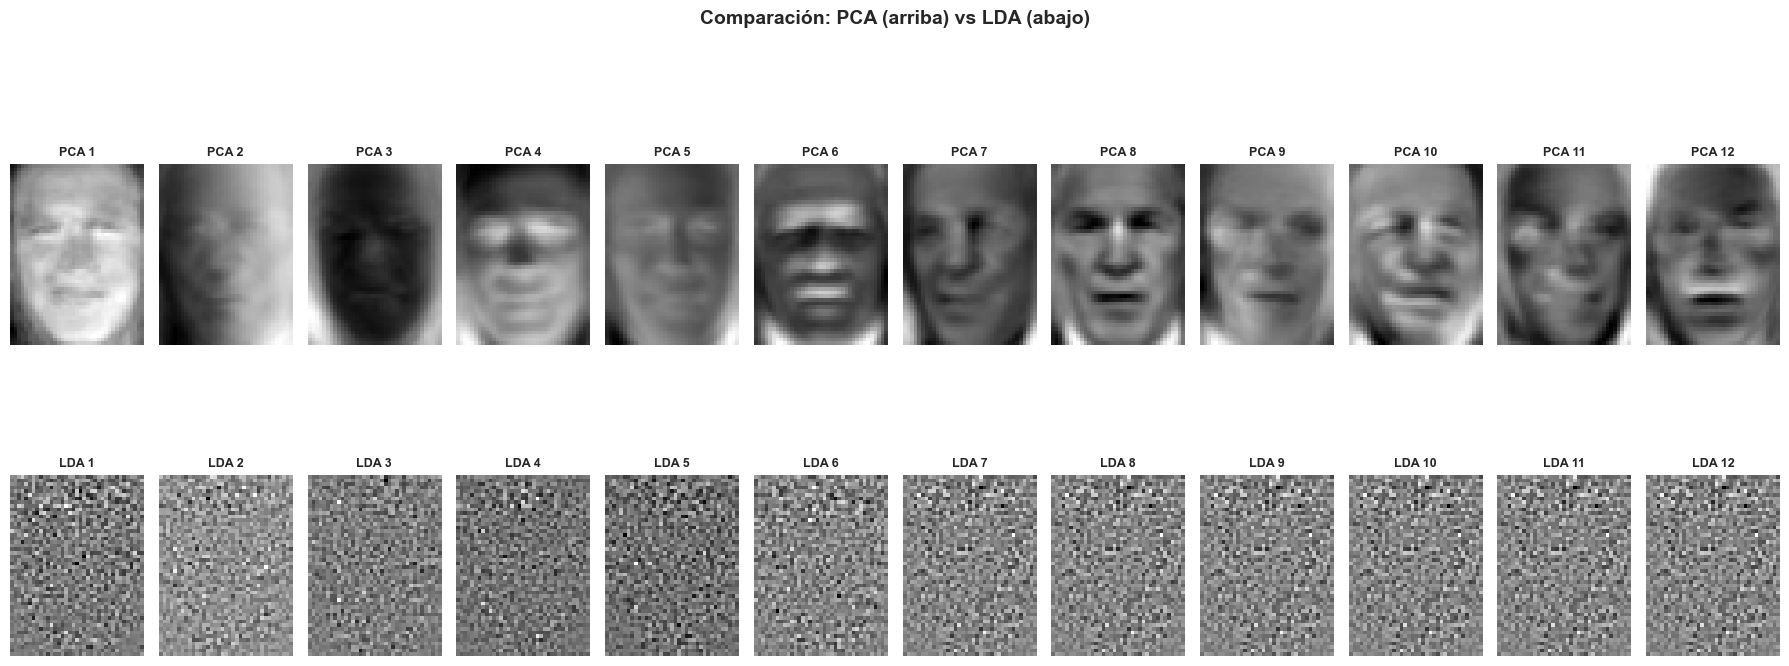

In [2]:
# Visualización de 12 componentes: PCA (arriba) vs LDA (abajo)
fig = plt.figure(figsize=(18, 8))

# PCA (usar pca_20 ya entrenado)
for i in range(12):
    ax = plt.subplot(2, 12, i + 1)
    eigenface = pca_20.components_[i].reshape((h, w))
    ax.imshow(eigenface, cmap='gray')
    ax.set_title(f'PCA {i+1}', fontsize=9, fontweight='bold')
    ax.axis('off')

# LDA (usar coeficientes como mapa aproximado)
for i in range(12):
    ax = plt.subplot(2, 12, i + 13)
    lda_face = lda.coef_[min(i, len(lda.coef_)-1)].reshape((h, w))
    ax.imshow(lda_face, cmap='gray')
    ax.set_title(f'LDA {i+1}', fontsize=9, fontweight='bold')
    ax.axis('off')

plt.suptitle('Comparación: PCA (arriba) vs LDA (abajo)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## EJERCICIO 4 (copiado): Top-5 Errores y Casos Difíciles

Mostramos los 5 errores más confiados (equivocados con alta confianza) y las 5 predicciones correctas más dudosas.

Top 5 ERRORES (alta confianza pero mal):
  1. Real: Ariel Sharon    → Pred: Donald Rumsfeld (Conf: 0.903)
  2. Real: Hugo Chavez     → Pred: Colin Powell    (Conf: 0.853)
  3. Real: Donald Rumsfeld → Pred: Ariel Sharon    (Conf: 0.837)
  4. Real: Colin Powell    → Pred: George W Bush   (Conf: 0.816)
  5. Real: Donald Rumsfeld → Pred: George W Bush   (Conf: 0.801)

Top 5 CORRECTAS DIFÍCILES (baja confianza):
  1. Colin Powell    (Conf: 0.271)
  2. Tony Blair      (Conf: 0.309)
  3. Gerhard Schroeder (Conf: 0.327)
  4. Gerhard Schroeder (Conf: 0.334)
  5. Colin Powell    (Conf: 0.335)


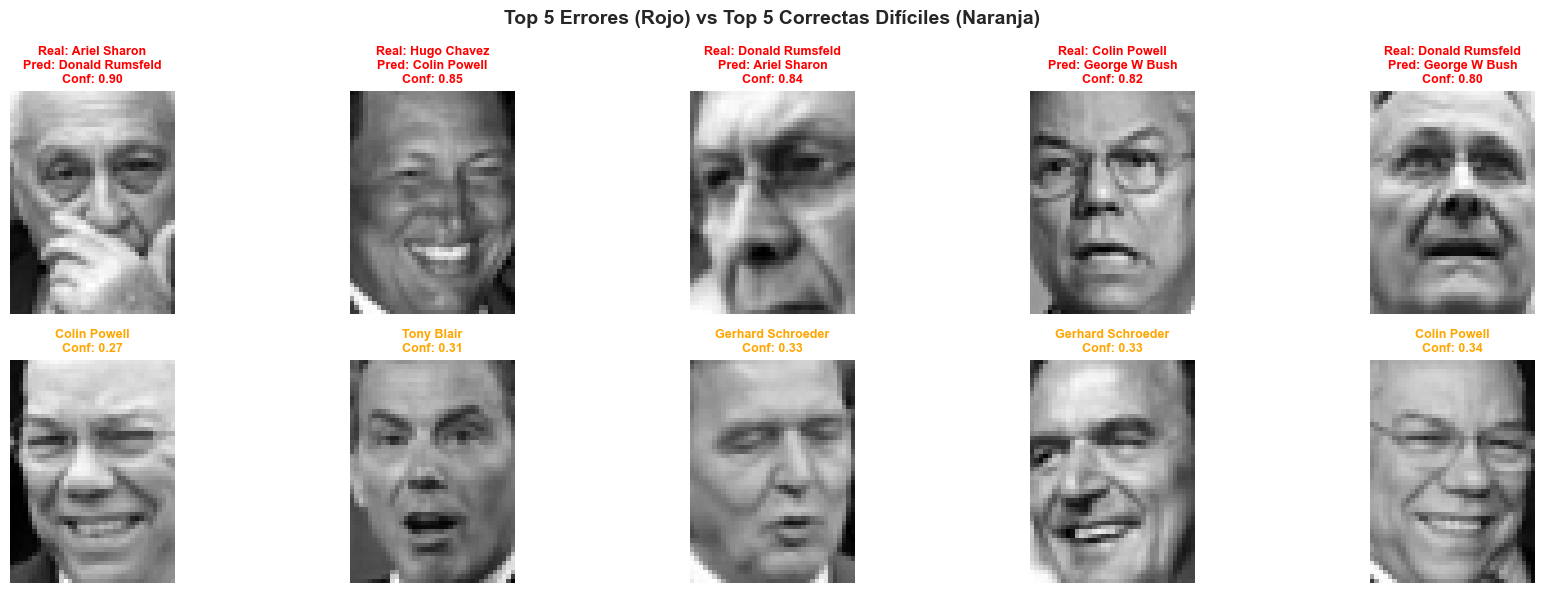

In [3]:
# Cálculo de tops por confianza usando SVM con probas (ya entrenado)
confidence = np.max(y_proba, axis=1)
is_correct = (y_pred_prob == y_test)

# Errores más confiados (incorrectos con mayor prob)
errors_idx = np.where(~is_correct)[0]
errors_conf = confidence[errors_idx]
top_errors = errors_idx[np.argsort(-errors_conf)[:5]]

# Correctas más dudosas (correctos con menor prob)
correct_idx = np.where(is_correct)[0]
correct_conf = confidence[correct_idx]
hard_correct = correct_idx[np.argsort(correct_conf)[:5]]

print("Top 5 ERRORES (alta confianza pero mal):")
for i, sample_idx in enumerate(top_errors):
    real = target_names[y_test[sample_idx]]
    pred = target_names[y_pred_prob[sample_idx]]
    conf = confidence[sample_idx]
    print(f"  {i+1}. Real: {real:15s} → Pred: {pred:15s} (Conf: {conf:.3f})")

# Visualización de imágenes
fig = plt.figure(figsize=(18, 6))
for idx, sample_idx in enumerate(top_errors):
    ax = plt.subplot(2, 5, idx + 1)
    img = X_test[sample_idx].reshape((h, w))
    ax.imshow(img, cmap='gray')
    real = target_names[y_test[sample_idx]]
    pred = target_names[y_pred_prob[sample_idx]]
    ax.set_title(f'Real: {real}\nPred: {pred}\nConf: {confidence[sample_idx]:.2f}',
                 fontsize=9, fontweight='bold', color='red')
    ax.axis('off')

print("\nTop 5 CORRECTAS DIFÍCILES (baja confianza):")
for i, sample_idx in enumerate(hard_correct):
    real = target_names[y_test[sample_idx]]
    conf = confidence[sample_idx]
    print(f"  {i+1}. {real:15s} (Conf: {conf:.3f})")

for idx, sample_idx in enumerate(hard_correct):
    ax = plt.subplot(2, 5, idx + 6)
    img = X_test[sample_idx].reshape((h, w))
    ax.imshow(img, cmap='gray')
    real = target_names[y_test[sample_idx]]
    ax.set_title(f'{real}\nConf: {confidence[sample_idx]:.2f}',
                 fontsize=9, fontweight='bold', color='orange')
    ax.axis('off')

plt.suptitle('Top 5 Errores (Rojo) vs Top 5 Correctas Difíciles (Naranja)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## EJERCICIO EXTRA A: Búsqueda de Vecinos Más Cercanos (Galería)

Para 3 imágenes de prueba, mostramos el query y sus 5 vecinos más cercanos en el espacio PCA y en el espacio LDA.

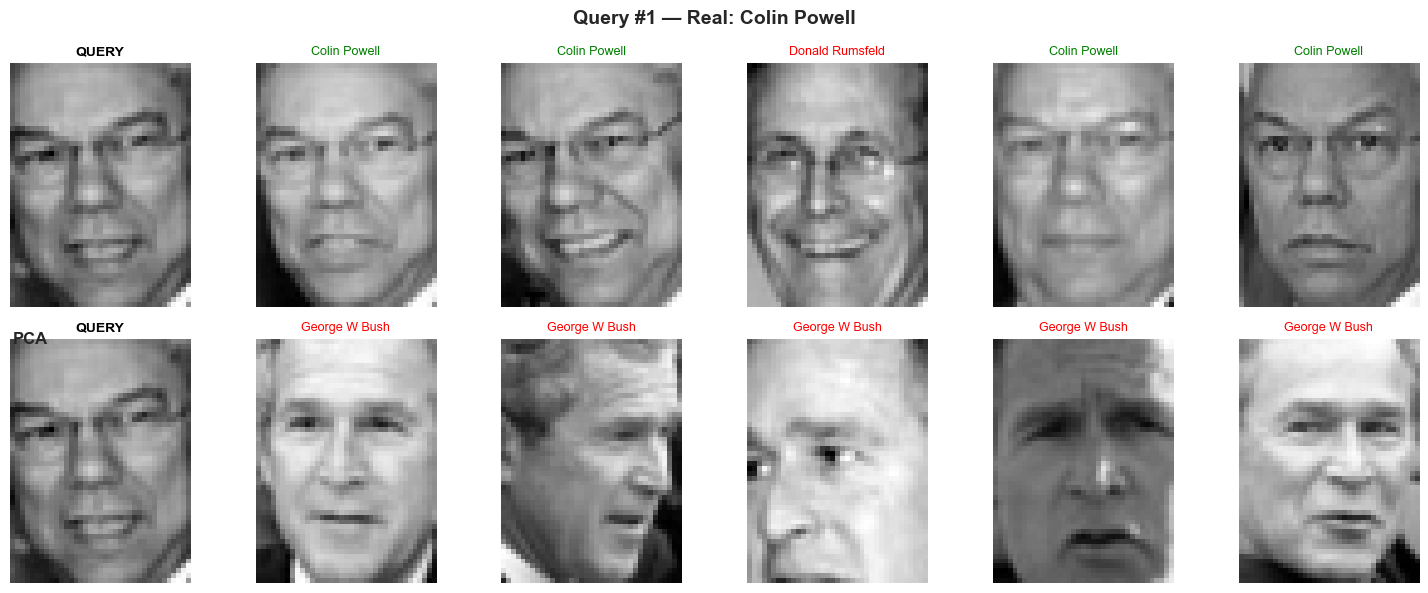

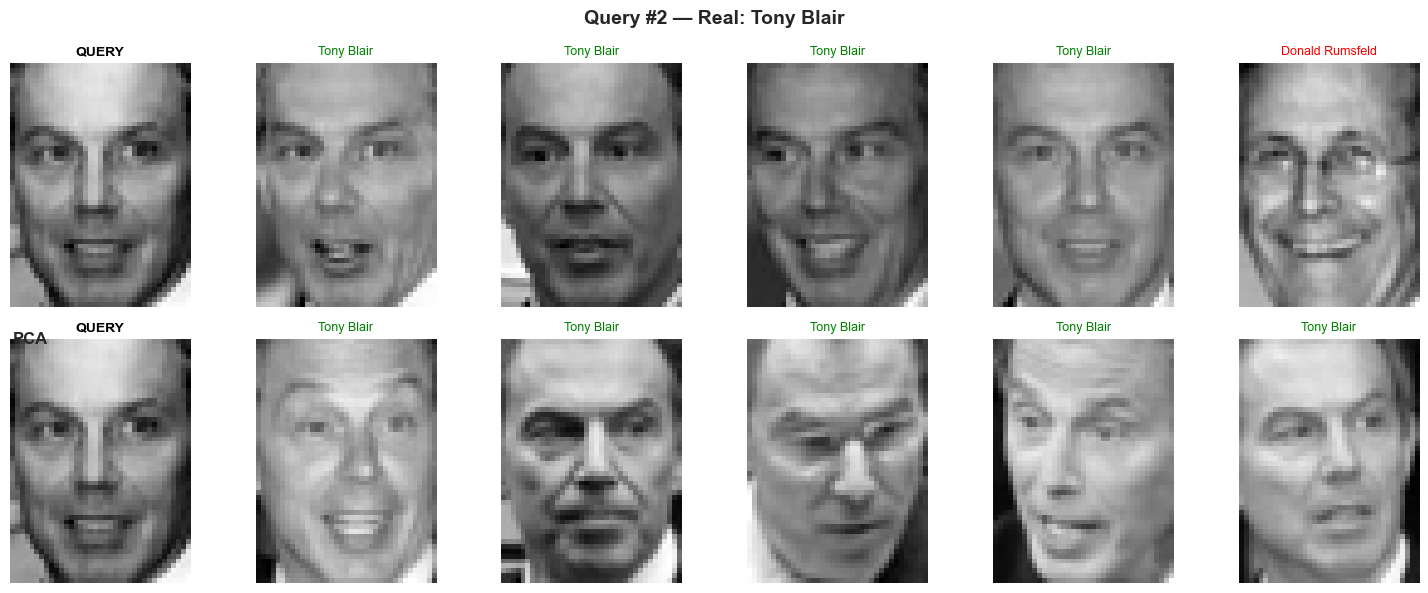

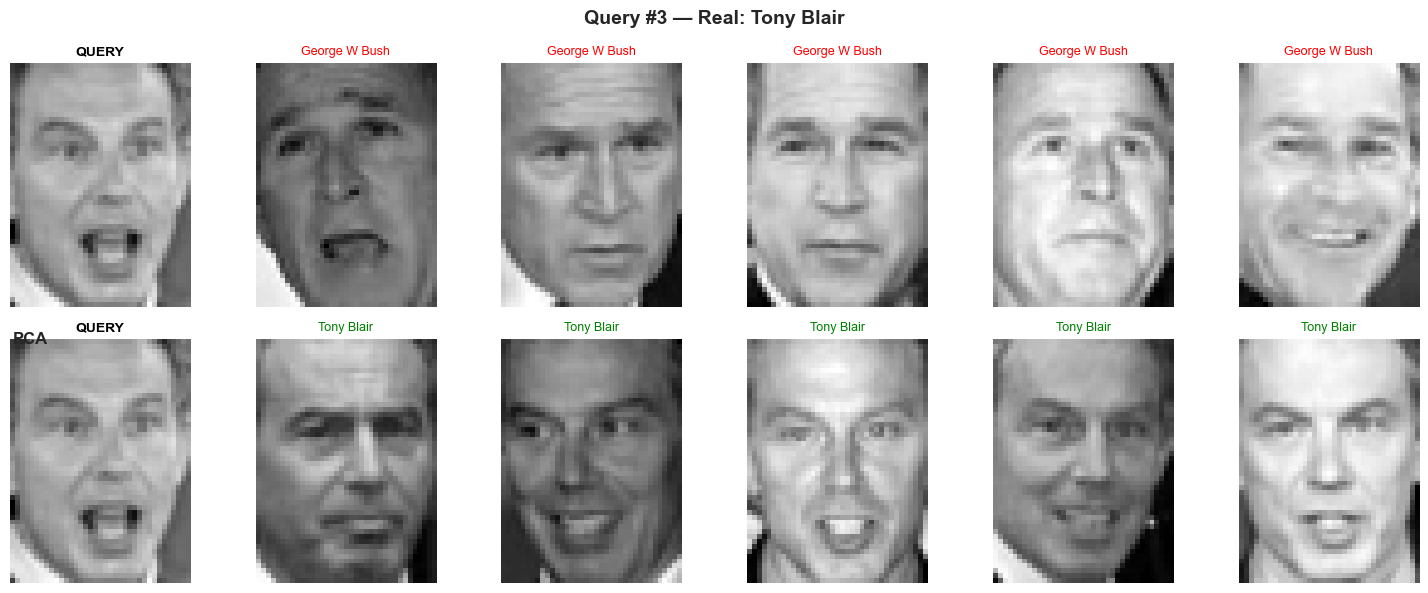

In [4]:
# k-NN visual en PCA y LDA
rng = np.random.RandomState(42)
queries = rng.choice(len(X_test), size=3, replace=False)
K = 5

# Precomputar representaciones
X_test_pca = X_test_pca_50
X_train_pca = pca_50.transform(X_train)
X_test_lda = X_test_lda
X_train_lda = X_train_lda

for qi, q_idx in enumerate(queries):
    # Distancias en PCA
    d_pca = cdist(X_test_pca[q_idx:q_idx+1], X_train_pca, metric='euclidean').ravel()
    nn_pca_idx = np.argsort(d_pca)[:K]

    # Distancias en LDA
    d_lda = cdist(X_test_lda[q_idx:q_idx+1], X_train_lda, metric='euclidean').ravel()
    nn_lda_idx = np.argsort(d_lda)[:K]

    fig = plt.figure(figsize=(15, 6))
    fig.suptitle(f'Query #{qi+1} — Real: {target_names[y_test[q_idx]]}', fontsize=14, fontweight='bold')

    # Mostrar query
    ax = plt.subplot(2, K+1, 1)
    ax.imshow(X_test[q_idx].reshape((h, w)), cmap='gray')
    ax.set_title('QUERY', fontsize=10, fontweight='bold', color='black')
    ax.axis('off')

    # Vecinos PCA
    for j, ni in enumerate(nn_pca_idx):
        ax = plt.subplot(2, K+1, 2 + j)
        ax.imshow(X_train[ni].reshape((h, w)), cmap='gray')
        lab = target_names[y_train[ni]]
        color = 'green' if lab == target_names[y_test[q_idx]] else 'red'
        ax.set_title(lab, fontsize=9, color=color)
        ax.axis('off')

    # Etiqueta de fila
    ax = plt.subplot(2, K+1, K+2)
    ax.axis('off')
    ax.text(0, 0.5, 'PCA', fontsize=12, fontweight='bold')

    # Vecinos LDA
    ax = plt.subplot(2, K+1, K+2)  # placeholder alineación
    for j, ni in enumerate(nn_lda_idx):
        ax = plt.subplot(2, K+1, K+2 + 1 + j)
        ax.imshow(X_train[ni].reshape((h, w)), cmap='gray')
        lab = target_names[y_train[ni]]
        color = 'green' if lab == target_names[y_test[q_idx]] else 'red'
        ax.set_title(lab, fontsize=9, color=color)
        ax.axis('off')

    # Etiqueta de fila LDA (columna 1 de fila 2)
    ax = plt.subplot(2, K+1, K+1 + 1)
    ax.imshow(X_test[q_idx].reshape((h, w)), cmap='gray')
    ax.set_title('QUERY', fontsize=10, fontweight='bold', color='black')
    ax.axis('off')

    plt.tight_layout()
    plt.show()

## EJERCICIO EXTRA B: Pares de Clases Más Confundidas (Galería)

Identificamos los pares (Real→Predicho) con más confusiones y mostramos ejemplos visuales lado a lado.

Top 1: George W Bush → Colin Powell (9 confusiones)


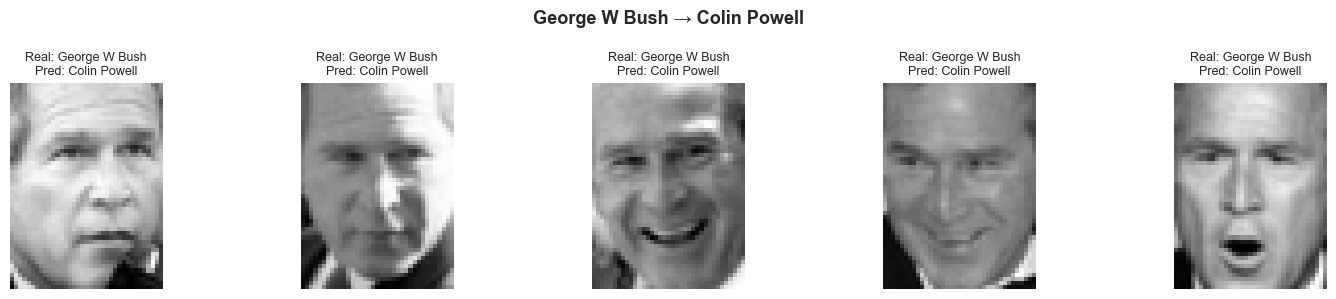

Top 2: Donald Rumsfeld → George W Bush (7 confusiones)


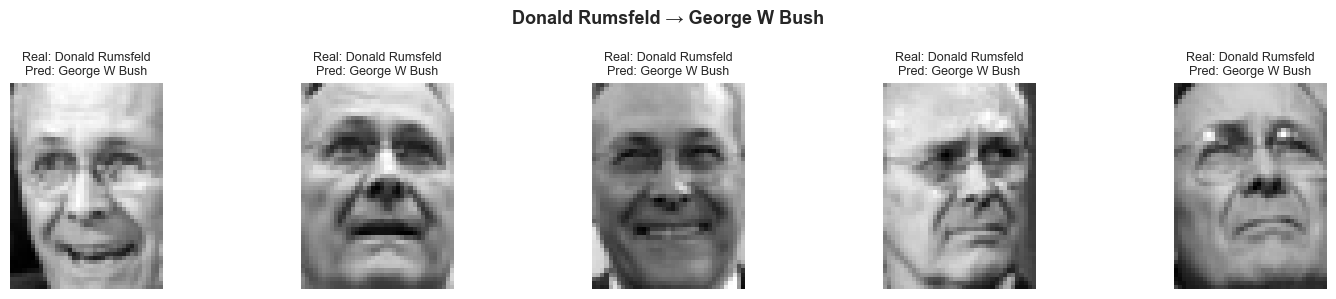

Top 3: Tony Blair → Gerhard Schroeder (6 confusiones)


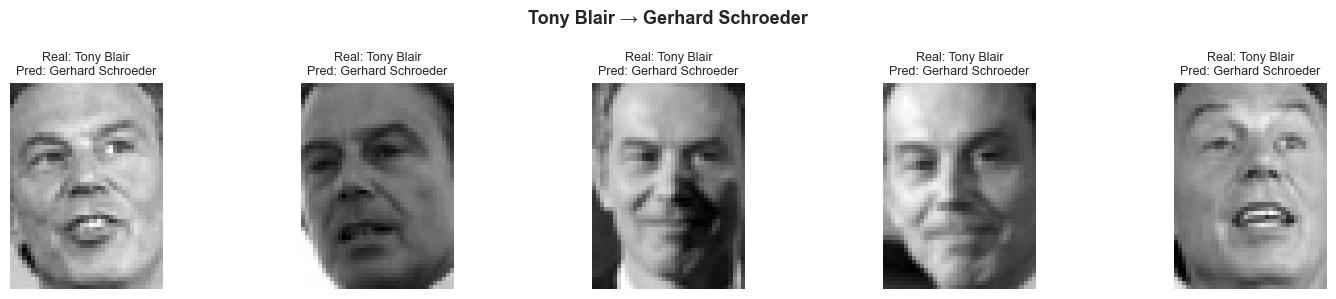

In [5]:
# Galería de confusiones principales
from collections import Counter

cm = confusion_matrix(y_test, y_pred_prob)
# Eliminar diagonal para buscar top confusiones
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)

# Obtener top 3 pares con más confusión
pairs = []
for i in range(cm_off.shape[0]):
    for j in range(cm_off.shape[1]):
        if cm_off[i, j] > 0:
            pairs.append(((i, j), cm_off[i, j]))

pairs_sorted = sorted(pairs, key=lambda x: -x[1])[:3]

for rank, ((true_id, pred_id), count) in enumerate(pairs_sorted, 1):
    print(f"Top {rank}: {target_names[true_id]} → {target_names[pred_id]} ({count} confusiones)")
    # índices de ejemplos concretos
    idxs = np.where((y_test == true_id) & (y_pred_prob == pred_id))[0][:5]

    cols = len(idxs)
    if cols == 0:
        continue
    fig, axes = plt.subplots(1, cols, figsize=(3*cols, 3))
    fig.suptitle(f'{target_names[true_id]} → {target_names[pred_id]}', fontsize=13, fontweight='bold')
    if cols == 1:
        axes = [axes]
    for k, idx in enumerate(idxs):
        axes[k].imshow(X_test[idx].reshape((h, w)), cmap='gray')
        axes[k].set_title(f'Real: {target_names[true_id]}\nPred: {target_names[pred_id]}', fontsize=9)
        axes[k].axis('off')
    plt.tight_layout()
    plt.show()

## EJERCICIO EXTRA C: Prototipo de Clase vs Outliers

Para dos clases con más muestras, mostramos el "promedio" (prototipo) y los 3 ejemplos más alejados (outliers) de esa clase.

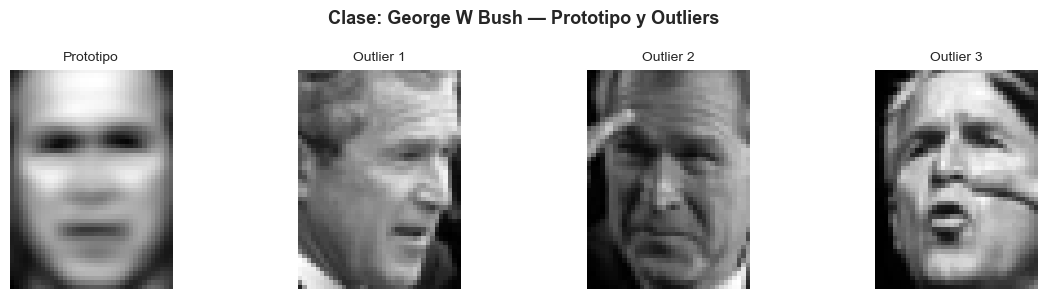

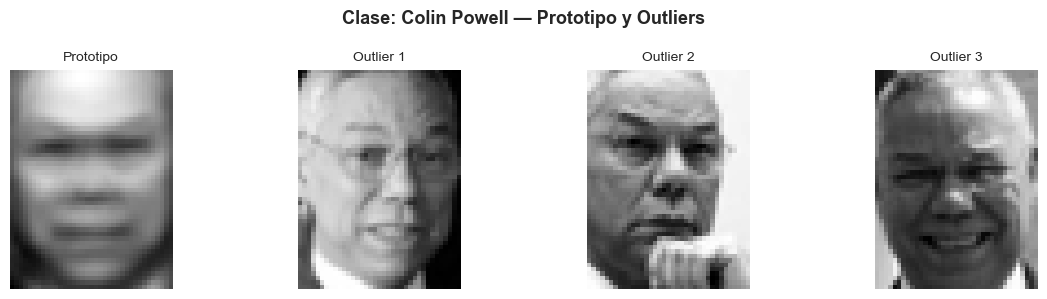

In [6]:
# Prototipos y outliers (distancia en espacio original)
# Contar muestras por clase
counts = np.bincount(y_train)
top_classes = np.argsort(-counts)[:2]

for cls in top_classes:
    cls_name = target_names[cls]
    cls_idx = np.where(y_train == cls)[0]
    Xc = X_train[cls_idx]

    proto = Xc.mean(axis=0)  # prototipo (media)
    dists = cdist(Xc, proto[None, :], metric='euclidean').ravel()
    out_idx_local = np.argsort(-dists)[:3]

    fig, axes = plt.subplots(1, 4, figsize=(12, 3))
    fig.suptitle(f'Clase: {cls_name} — Prototipo y Outliers', fontsize=13, fontweight='bold')

    # Prototipo
    axes[0].imshow(proto.reshape((h, w)), cmap='gray')
    axes[0].set_title('Prototipo', fontsize=10)
    axes[0].axis('off')

    # Outliers
    for j in range(3):
        axes[j+1].imshow(Xc[out_idx_local[j]].reshape((h, w)), cmap='gray')
        axes[j+1].set_title(f'Outlier {j+1}', fontsize=10)
        axes[j+1].axis('off')

    plt.tight_layout()
    plt.show()

## EJERCICIO EXTRA D: Occlusion Sensitivity Heatmaps

Para 2 imágenes, ocultamos parches y medimos la caída de probabilidad del SVM para la clase predicha. Mostramos: original, mapa de importancia (calor) y superposición.

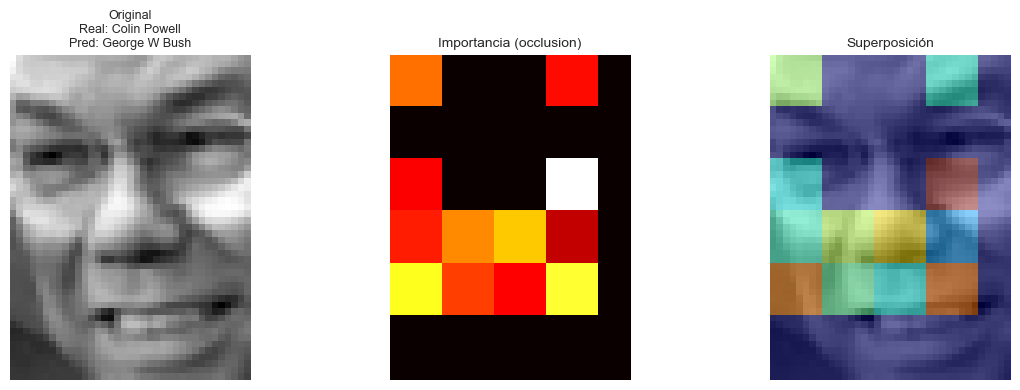

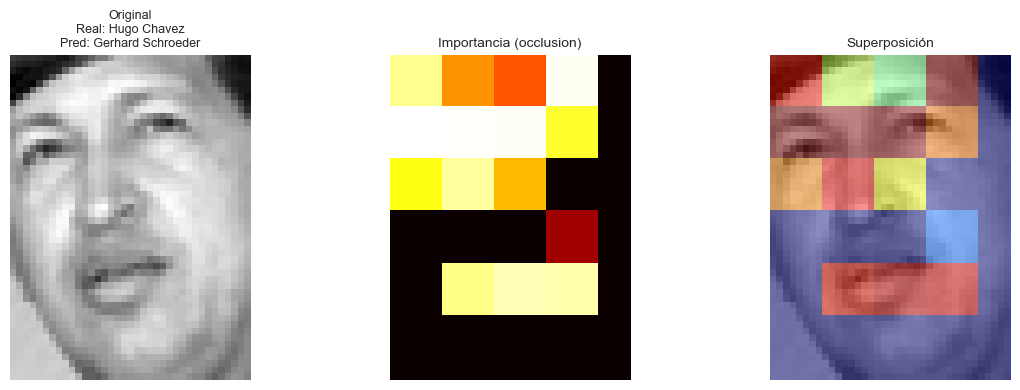

In [7]:
# Occlusion heatmaps (parche 12x12, stride 8) para 2 imágenes
patch = 12
stride = 8
rng = np.random.RandomState(0)
indices = rng.choice(len(X_test), size=2, replace=False)

for idx in indices:
    img = X_test[idx].reshape((h, w)).copy()

    # Probabilidad base para la clase predicha
    base_proba = svm_prob.predict_proba(X_test_pca_50[idx:idx+1])[0]
    pred_cls = np.argmax(base_proba)
    base_score = base_proba[pred_cls]

    H = (h - patch) // stride + 1
    W = (w - patch) // stride + 1
    heat = np.zeros((H, W))

    for i in range(H):
        for j in range(W):
            occluded = img.copy()
            r0 = i * stride
            c0 = j * stride
            occluded[r0:r0+patch, c0:c0+patch] = 0.0
            x_occ = occluded.reshape(1, -1)
            x_occ_pca = pca_50.transform(x_occ)
            proba = svm_prob.predict_proba(x_occ_pca)[0, pred_cls]
            heat[i, j] = max(0.0, base_score - proba)

    # Normalizar y redimensionar heatmap al tamaño de imagen
    if heat.max() > 0:
        heat_n = heat / heat.max()
    else:
        heat_n = heat
    upscale = np.kron(heat_n, np.ones((stride, stride)))
    # recortar/ajustar a tamaño exacto
    up_h = min(upscale.shape[0], h)
    up_w = min(upscale.shape[1], w)
    heat_full = np.zeros_like(img)
    heat_full[:up_h, :up_w] = upscale[:up_h, :up_w]

    # Mostrar original, heatmap y overlay
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].imshow(img, cmap='gray')
    axs[0].set_title(f'Original\nReal: {target_names[y_test[idx]]}\nPred: {target_names[pred_cls]}', fontsize=9)
    axs[0].axis('off')

    im1 = axs[1].imshow(heat_full, cmap='hot')
    axs[1].set_title('Importancia (occlusion)', fontsize=10)
    axs[1].axis('off')

    axs[2].imshow(img, cmap='gray')
    axs[2].imshow(heat_full, cmap='jet', alpha=0.45)
    axs[2].set_title('Superposición', fontsize=10)
    axs[2].axis('off')

    plt.tight_layout()
    plt.show()

## EJERCICIO EXTRA E: Reconstrucciones Progresivas con PCA

Para 3 imágenes, mostramos original y reconstrucciones usando K ∈ {10, 25, 50} componentes.

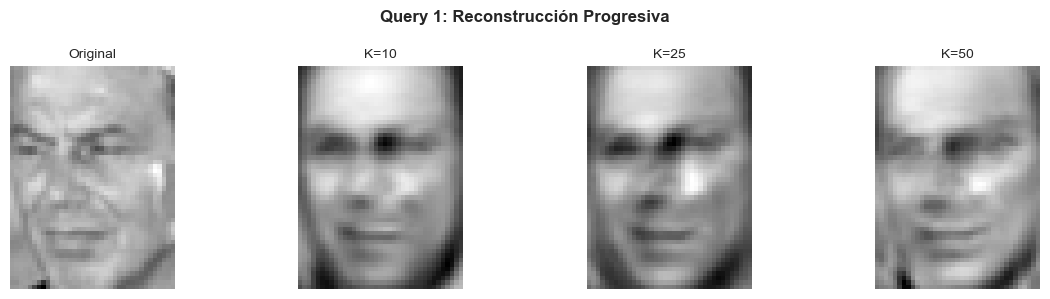

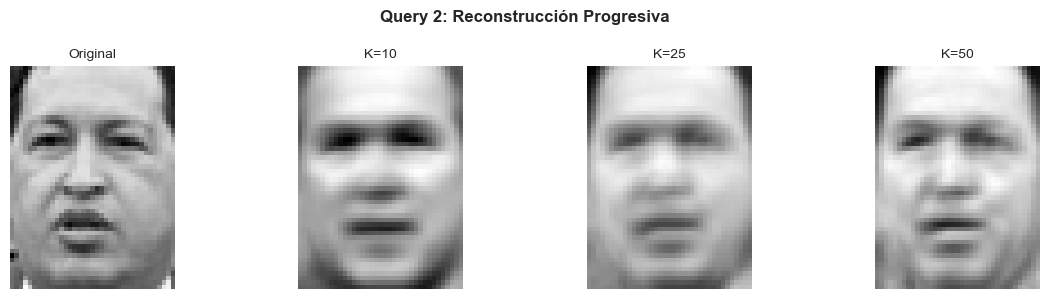

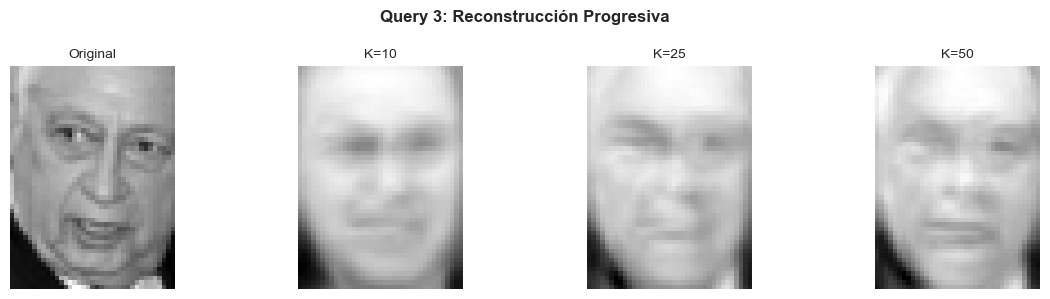

In [8]:
# Reconstrucciones con K componentes
Ks = [10, 25, 50]
rng = np.random.RandomState(1)
qs = rng.choice(len(X_test), size=3, replace=False)

for qi, idx in enumerate(qs):
    x = X_test[idx:idx+1]
    x_t = pca_50.transform(x)

    fig, axs = plt.subplots(1, len(Ks)+1, figsize=(12, 3))
    axs[0].imshow(x.reshape((h, w)), cmap='gray')
    axs[0].set_title('Original', fontsize=10)
    axs[0].axis('off')

    for j, K in enumerate(Ks):
        x_tk = x_t.copy()
        x_tk[:, K:] = 0.0
        x_rec = pca_50.inverse_transform(x_tk)
        axs[j+1].imshow(x_rec.reshape((h, w)), cmap='gray')
        axs[j+1].set_title(f'K={K}', fontsize=10)
        axs[j+1].axis('off')

    fig.suptitle(f'Query {qi+1}: Reconstrucción Progresiva', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

## EJERCICIO EXTRA F: Retrieval Positivos vs Impostores (2 filas)

Para 3 queries, mostramos 5 vecinos más cercanos de la misma clase (fila 1) y 5 impostores más cercanos (fila 2) en PCA50.

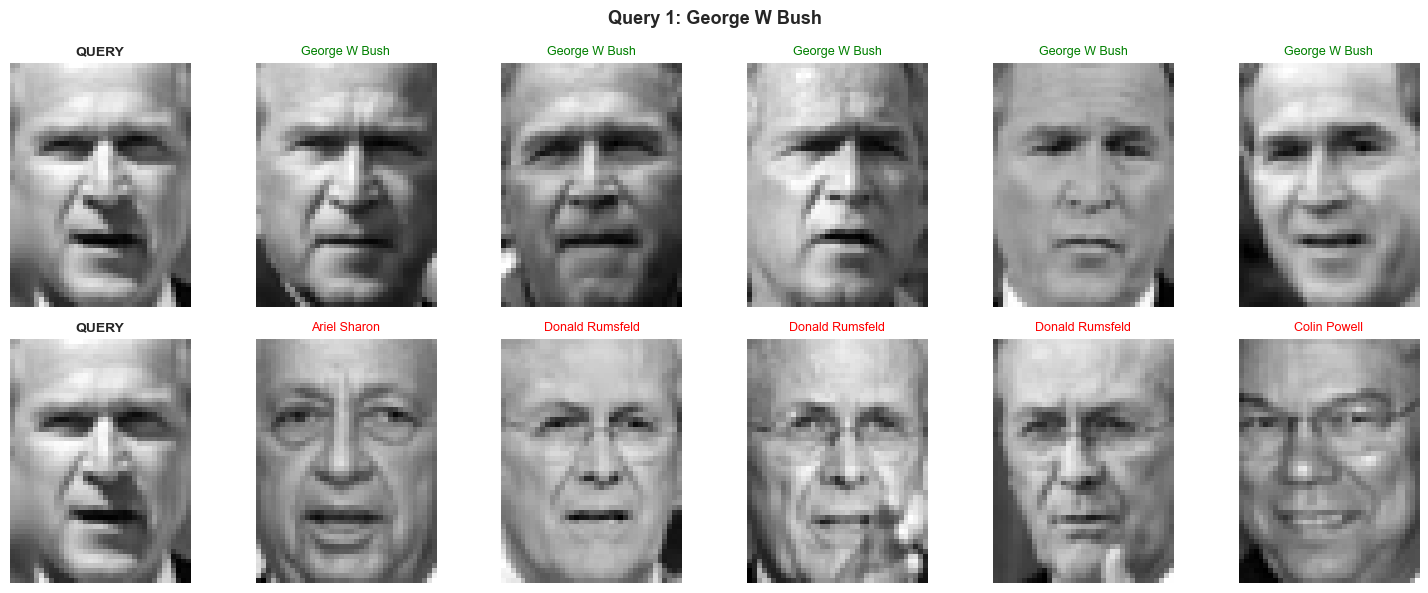

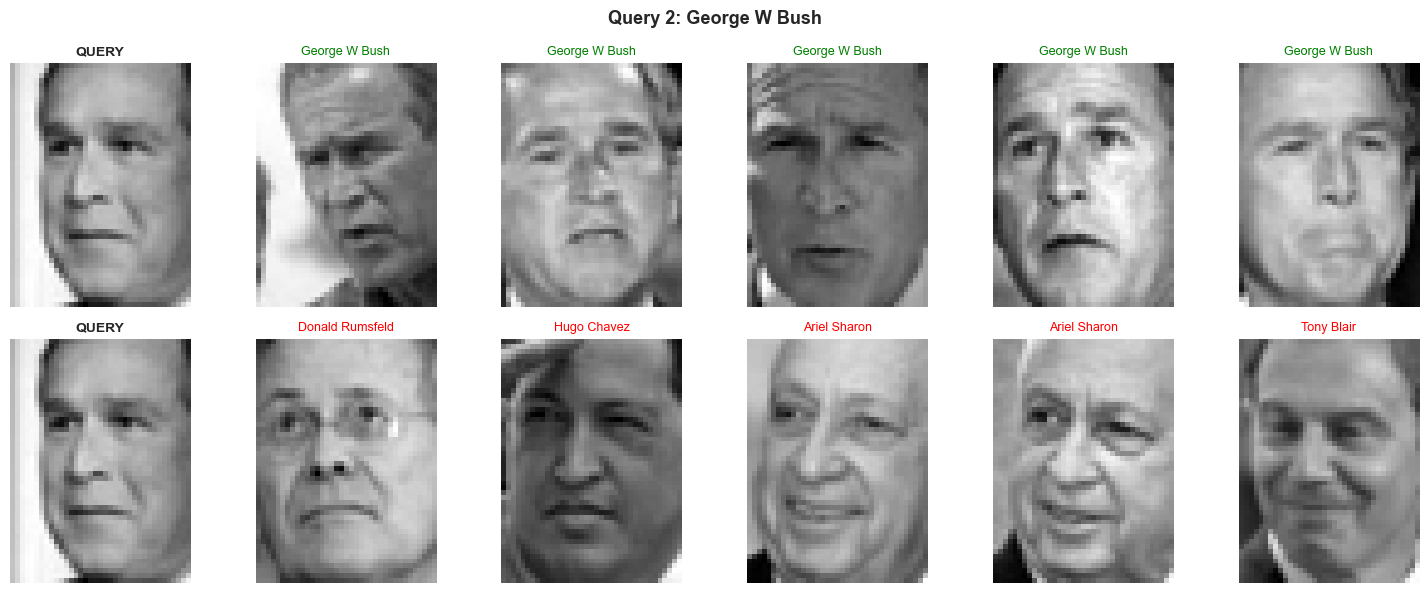

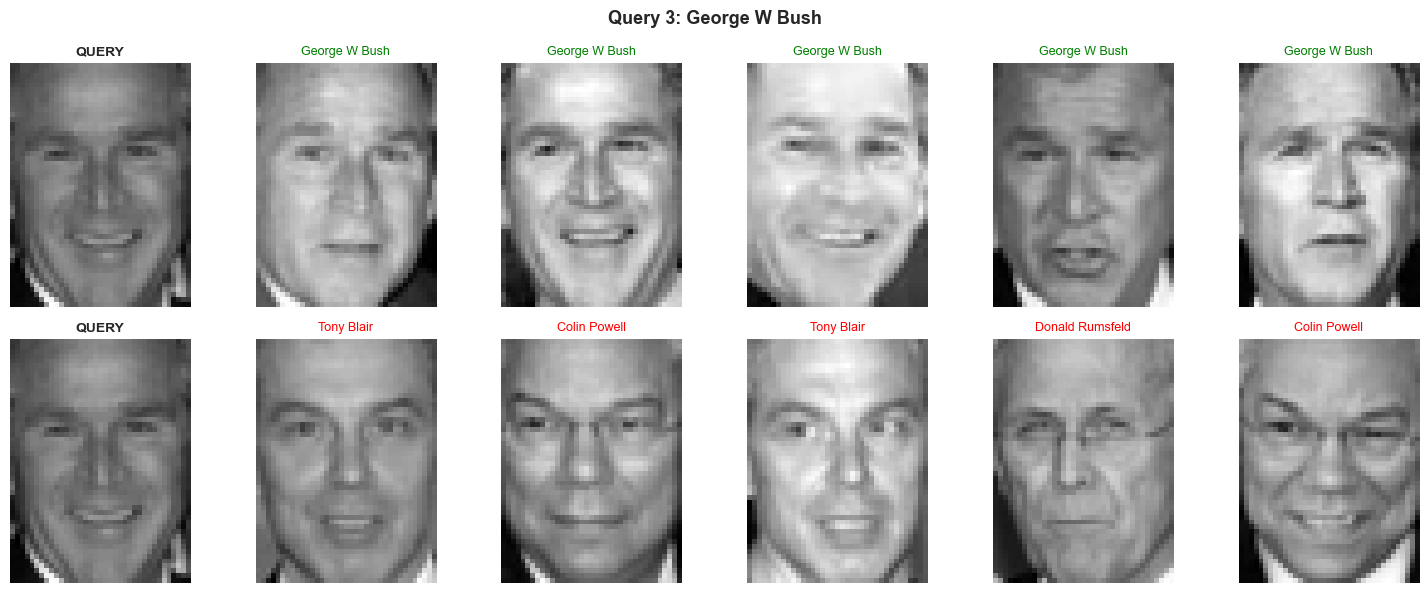

In [9]:
# Extra F: Retrieval Positivos vs Impostores (2 filas)
# Dos filas por query: misma clase (verde) y impostores (rojo)
from scipy.spatial.distance import cdist

rng = np.random.RandomState(7)
qs = rng.choice(len(X_test), size=3, replace=False)
K = 5

for qi, q_idx in enumerate(qs):
    q_lab = y_test[q_idx]
    xq = X_test_pca_50[q_idx:q_idx+1]

    same_idx = np.where(y_train == q_lab)[0]
    diff_idx = np.where(y_train != q_lab)[0]

    d_same = cdist(xq, X_train_pca_50[same_idx], metric='euclidean').ravel()
    d_diff = cdist(xq, X_train_pca_50[diff_idx], metric='euclidean').ravel()

    top_same_local = np.argsort(d_same)[:K]
    top_diff_local = np.argsort(d_diff)[:K]

    top_same = same_idx[top_same_local]
    top_diff = diff_idx[top_diff_local]

    fig = plt.figure(figsize=(15, 6))
    fig.suptitle(f'Query {qi+1}: {target_names[q_lab]}', fontsize=13, fontweight='bold')

    # Mostrar query
    ax = plt.subplot(2, K+1, 1)
    ax.imshow(X_test[q_idx].reshape((h, w)), cmap='gray')
    ax.set_title('QUERY', fontsize=10, fontweight='bold')
    ax.axis('off')

    # Fila 1: mismos
    for j, ni in enumerate(top_same):
        ax = plt.subplot(2, K+1, 2 + j)
        ax.imshow(X_train[ni].reshape((h, w)), cmap='gray')
        ax.set_title(target_names[y_train[ni]], fontsize=9, color='green')
        ax.axis('off')

    # Fila 2: impostores
    ax = plt.subplot(2, K+1, K+2)
    ax.imshow(X_test[q_idx].reshape((h, w)), cmap='gray')
    ax.set_title('QUERY', fontsize=10, fontweight='bold')
    ax.axis('off')

    for j, ni in enumerate(top_diff):
        ax = plt.subplot(2, K+1, K+2 + 1 + j)
        ax.imshow(X_train[ni].reshape((h, w)), cmap='gray')
        ax.set_title(target_names[y_train[ni]], fontsize=9, color='red')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

## EJERCICIO EXTRA G: Galería de desacuerdos SVM vs k-NN
Visualiza ejemplos donde `SVM` y `k-NN` discrepan en PCA-50: cada imagen muestra la clase real y, debajo, las predicciones de ambos modelos coloreadas (verde si aciertan, rojo si fallan).

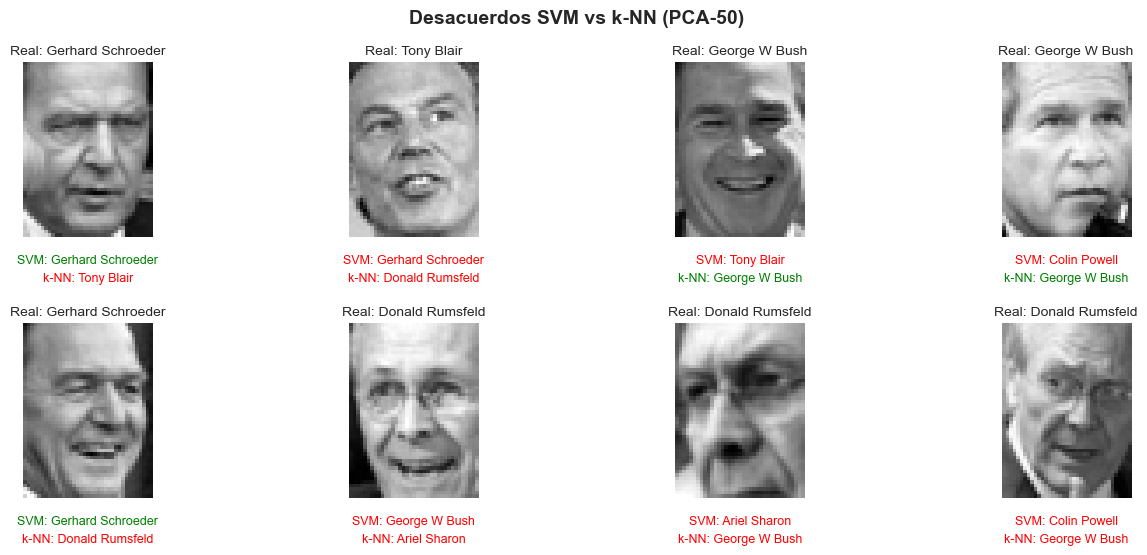

In [10]:
# SVM vs k-NN desacuerdos en PCA-50
from sklearn.neighbors import KNeighborsClassifier

# Entrenar k-NN sobre PCA-50
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_pca_50, y_train)

# Predicciones
y_pred_svm = svm_prob.predict(X_test_pca_50)
y_pred_knn = knn.predict(X_test_pca_50)

# Índices donde discrepan
idx_dis = np.where(y_pred_svm != y_pred_knn)[0]

if len(idx_dis) == 0:
    print('No hay desacuerdos entre SVM y k-NN en el conjunto de test.')
else:
    N = min(8, len(idx_dis))
    idx_vis = idx_dis[:N]

    rows = 2
    cols = int(np.ceil(N / rows))
    plt.figure(figsize=(3.5*cols, 6))
    plt.suptitle('Desacuerdos SVM vs k-NN (PCA-50)', fontsize=14, fontweight='bold')

    for i, ind in enumerate(idx_vis):
        ax = plt.subplot(rows, cols, i+1)
        ax.imshow(X_test[ind].reshape((h, w)), cmap='gray')
        real_lab = target_names[y_test[ind]]
        svm_lab = target_names[y_pred_svm[ind]]
        knn_lab = target_names[y_pred_knn[ind]]

        ax.set_title(f'Real: {real_lab}', fontsize=10)
        svm_color = 'green' if y_pred_svm[ind] == y_test[ind] else 'red'
        knn_color = 'green' if y_pred_knn[ind] == y_test[ind] else 'red'
        ax.text(0.5, -0.10, f'SVM: {svm_lab}', transform=ax.transAxes, ha='center', va='top', fontsize=9, color=svm_color)
        ax.text(0.5, -0.20, f'k-NN: {knn_lab}', transform=ax.transAxes, ha='center', va='top', fontsize=9, color=knn_color)
        ax.axis('off')

    plt.tight_layout(rect=(0, 0.05, 1, 1))
    plt.show()